# Exploration of Ramanujan's infinite series to estimate $\pi$

The motivation of this notebook is my fascination towards Ramanujan's infinite series of pi, especially the fact that he claims to have them "revealed" while asleep.
Reminded me of my Physics Professor Mr. Jacques Randria, who told me he often found solutions to complex homeworks when he was sleeping when he was in CPGE.

This notebook will thus be a bit informal as it was just a quick curiosity of mine.

Goal of this notebook : 
- implementing different Ramanujan's infinite series of $\pi$ .
- testing how well it performs, how quick it reaches a 100 and 200-decimal precision (in the sense of number of terms of the series added)
- PS: comparing to a traditionnal way to estimate it (using the power series expansion of arctan(x), which equals pi/4 for x=1)

Source used for the formulas : https://en.wikipedia.org/wiki/Approximations_of_pi

0% AI here, all code and text written by me

In [97]:
import numpy as np
import math_pi
import time
import matplotlib.pyplot as plt
from decimal import Decimal, getcontext

getcontext().prec = 240 # un peu plus pour avoir precision de 100 decimales

# pi = np.pi
# Unfortunately, Python float only contain 15 decimals, so we must use the library decimal in order to go over 15 decimals of pi.

pi = Decimal(math_pi.pi(b=201))

### 1st approximation : the 1st term of Ramanujan's original infinite series
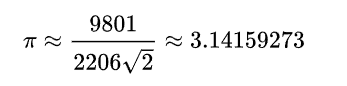

See the 2nd approximation to see the full series. Here we only take the 1st term

Results :

> We already get a 7 decimal precision

In [98]:
sqrt2 = Decimal(2).sqrt()
approx_1 = Decimal(9801) / (Decimal(2206) * sqrt2)
print("approx_1:" ,approx_1)
print("      pi:" ,pi)
print("    Diff:", pi - approx_1)

approx_1: 3.14159273001330566031399618902521551859958160711003355965653629012855145544132164274085408520970422809969870963489832800119862152842091464667385194766012490563939151150396244664542051560784188961370375760285523157527530841196370004677112403
      pi: 3.141592653589793238462643383279502884197169399375105820974944592307816406286208998628034825342117067982148086513282306647093844609550582231725359408128481117450284102701938521105559644622948954930381964
    Diff: -7.642351242185135280574571263440241220773492773868159169782073504915511264411281925986758716011755062312161602135410477691887033241494849253953164378818910740880202392553986087098489293468332179360285523157527530841196370004677112403E-8


### 2nd approximation : Ramanujan's original infinite series
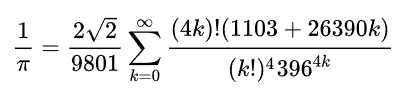

Results :

> by summing 13 terms, we get a 100-decimal precision

> by summing 26 terms, we get a 200-decimal precision

In [99]:
def fact(k): # on definit une factorielle recursive, plus rapide qu'une boucle 
    if k>1:
        return fact(k-1)*(k)
    return 1

def approx_2(n):
    S=0 # the sum after the factor
    for k in range(0,n):
        S+= Decimal(fact(4*k) * (1103 + 26390*k)) / Decimal(( fact(k)**4 *396**(4*k) ))
    return Decimal( 2*sqrt2 / Decimal(9801 )) * S

inv_pi_approx_2 = approx_2(26)

pi_approx_2 = 1 / inv_pi_approx_2
print("approx_1:" ,pi_approx_2)
print("      pi:" ,pi)
print("    Diff:",pi - pi_approx_2)

approx_1: 3.14159265358979323846264338327950288419716939937510582097494459230781640628620899862803482534211706798214808651328230664709384460955058223172535940812848111745028410270193852110555964462294895493038196442881150253778881377802341609962751193
      pi: 3.141592653589793238462643383279502884197169399375105820974944592307816406286208998628034825342117067982148086513282306647093844609550582231725359408128481117450284102701938521105559644622948954930381964
    Diff: -4.2881150253778881377802341609962751193E-202


### 3rd approximation : variation of Ramanujan's infinite series
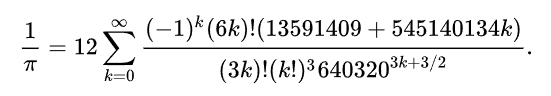

This one was used in 1989 by the Chudnivsky brothers to compute over 1 billion decimal of $\pi$ with a supercomputer IBM 3090

Results :

> by summing 8 terms, we get a 100-decimal precision

> by summing 15 terms, we get a 200-decimal precision

In [100]:
# here we have a pb with the power 3/2 which is a float, so to have C^3/2, we must do C*C^1/2 with C^1/2 computed with Decimal.sqrt(). 
# With C=640320, we thus decompose C^(3k+3/2) in C^(3k)*C*C^1/2

def approx_3(n):
    S=0 # the sum after the factor 12
    C=640320
    C12=Decimal(C).sqrt()
    C32=C*C12 # = C^(3/2)
    for k in range(0,n):
        S+= Decimal ((-1)**k * fact(6*k) * (13591409 + 545140134 * k ) )/ Decimal( fact(3*k) * fact(k)**3 * 640320**(3*k) * C32)
    return Decimal( 12 * S)

inv_pi_approx_3 = approx_3(15)

pi_approx_3 = Decimal( 1 / inv_pi_approx_3 )
print("approx_1:" ,pi_approx_3)
print("      pi:" ,pi)
print("    Diff:",pi - pi_approx_3)


approx_1: 3.14159265358979323846264338327950288419716939937510582097494459230781640628620899862803482534211706798214808651328230664709384460955058223172535940812848111745028410270193852110555964462294895493038196442881097566051389716999689215408043191
      pi: 3.141592653589793238462643383279502884197169399375105820974944592307816406286208998628034825342117067982148086513282306647093844609550582231725359408128481117450284102701938521105559644622948954930381964
    Diff: -4.2881097566051389716999689215408043191E-202


### Conclusion 1

We can thus conclude that Ramanujan was right... and what's most striking is that for every 1 more term added, it adds many many digits of precisions !! wow

PS : I wanted to compare how quick Ramanujan series are compared to other ways of calculating pi, namely with the arctan series as $ arctan(1)= \pi / 4$

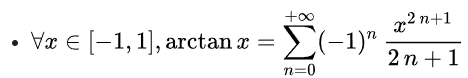

(source of this image : https://fr.wikipedia.org/wiki/Formulaire_de_d%C3%A9veloppements_en_s%C3%A9ries)

In [102]:
def arctan_1(n): # simplified for x=1
    S=0
    for k in range(0,n):
        S+=Decimal((-1)**k )/ Decimal(2*k+1 )
    return S # return pi/4

pi_approx_4 = 4*arctan_1(10**4)
print("approx_1:" ,pi_approx_4)
print("      pi:" ,pi)
print("    Diff:",pi - pi_approx_4)


approx_1: 3.14149265359004323845951838337481537878701364274418046051347980547439567069002885087063294318676551571244918027087959521665613834672305324085742516537014547652366702419402485256552534094998793885940729109008436960753359009301135666753647446
      pi: 3.141592653589793238462643383279502884197169399375105820974944592307816406286208998628034825342117067982148086513282306647093844609550582231725359408128481117450284102701938521105559644622948954930381964
    Diff: 0.00009999999975000000312499990468750541015575663092536046146478683342073559618014775740188215535155226969890624240271143043770626282752899086793424275833564092661707850791366854003430367296101607097467290991563039246640990698864333246352554


### Conslusion 2

> We observe empiricallly that we need to sum 10^k terms to approach k digits of pi... (tested for k=0 to k=8)

> The complexity is thus exponential regarding the number of digits we want... Ramanujan is better !